Deep Reinforcement Learning
Assignment 1
Part 1 (MAB - Multi-Armed Bandit)
Group Number - 163

In [3]:
# Installing Required Libraries 
import pandas as pd
import numpy as np
import random 
import matplotlib.pyplot as plt

TASK 1: DATASET DESIGN & ENVIRONMENT SETUP

In [4]:
# Setting seeds for reproducibility - ensures we get the same random numbers
G = 163
random.seed(G)
np.random.seed(G)

In [5]:
# Calculate number of medicines (K = (G % 3) + 5)

K = (G % 3) + 5
print(f"Group Number(G): {G}")
print(f"Number of Medicines(K): {K}")

Group Number(G): 163
Number of Medicines(K): 6


In [6]:
# Calculate hidden success probabilities for each medicine (Pi = 0.4 + ((G + i) % 6) * 0.07)

hidden_probs = []
for i in range(K):
    pi = 0.4 + ((G+i)%6) * 0.07
    hidden_probs.append(pi)

print("Hidden Success Probabilities")
for i,p in enumerate(hidden_probs, start = 1):
    print(f"Medicine: {i}: {p:.2f}")

print(f"\nBest Medicine: Medicine {np.argmax(hidden_probs)+1} "
        f"(Probability = {max(hidden_probs):.2f})")

Hidden Success Probabilities
Medicine: 1: 0.47
Medicine: 2: 0.54
Medicine: 3: 0.61
Medicine: 4: 0.68
Medicine: 5: 0.75
Medicine: 6: 0.40

Best Medicine: Medicine 5 (Probability = 0.75)


In [7]:
# Generating Dataset 
# patient_id: 0 to 999
# severity_score: (patient_id % 5) + 1

num_patients = 1000

# Creating base dataset using pre-known columns
df_base = pd.DataFrame({
    'patient_id': range(num_patients),
    'serverity_score': [(pid % 5)+1 for pid in range(num_patients)]
})

# Adding placeholder columns that algorithms will fill dynamically
df_base['assigned_medicine'] = None
df_base['clinical_outcome']  = None
df_base['utility_score']     = None

# Displaying Dataset Sample
print("Base patient dataset:")
print(df_base.sample(10).to_string(index=False))
print(f"\nTotal patients: {len(df_base)}")
print(f"Severity score range: {df_base['serverity_score'].min()} to "
      f"{df_base['serverity_score'].max()}")


Base patient dataset:
 patient_id  serverity_score assigned_medicine clinical_outcome utility_score
        613                4              None             None          None
        585                1              None             None          None
        799                5              None             None          None
        822                3              None             None          None
        774                5              None             None          None
        697                3              None             None          None
        512                3              None             None          None
        333                4              None             None          None
        297                3              None             None          None
        133                4              None             None          None

Total patients: 1000
Severity score range: 1 to 5


Yugansh Jindal

Priyanshi Singh

Niti Jain


Final Medicine Selection Counts:
Medicine 0: 82
Medicine 1: 127
Medicine 2: 135
Medicine 3: 311
Medicine 4: 283
Medicine 5: 62

Estimated Mean Rewards:
Medicine 0: 0.3134
Medicine 1: 0.3953
Medicine 2: 0.4089
Medicine 3: 0.5190
Medicine 4: 0.5071
Medicine 5: 0.2548

Total Cumulative Reward: 451.8
Best Medicine Identified by UCB: 3
   patient_id  serverity_score  assigned_medicine  clinical_outcome  \
0           0                1                  0                 1   
1           1                2                  1                 0   
2           2                3                  2                 1   
3           3                4                  3                 0   
4           4                5                  4                 0   
5           5                1                  5                 0   
6           6                2                  0                 0   
7           7                3                  2                 1   
8           8              

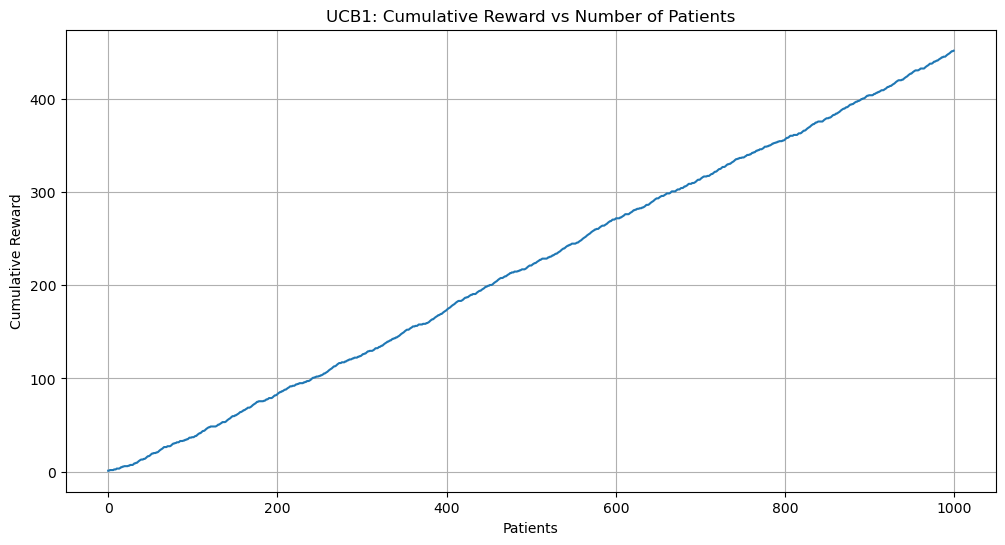

In [8]:
import math
num_patients = 1000

medicine_counts = np.zeros(K)
medicine_rewards = np.zeros(K)

assigned_medicine = []
clinical_outcome = []
utility_score = []
P = [0.4 + ((G + i) % 6) * 0.07 for i in range(K)]

cumulative_rewards = []
total_reward = 0

for patient in range(num_patients):

    severity = df_base.loc[patient, 'serverity_score']

    # Initial exploration
    if patient < K:
        med = patient

    else:
        ucb_values = []

        for i in range(K):

            avg_reward = medicine_rewards[i] / medicine_counts[i]

            confidence = math.sqrt(
                (2 * math.log(patient + 1)) / medicine_counts[i]
            )

            ucb = avg_reward + confidence
            ucb_values.append(ucb)

        med = np.argmax(ucb_values)

    # Simulate recovery
    outcome = np.random.binomial(1, P[med])

    # Utility score
    reward = outcome * (1 - severity / 10)

    # Update stats
    medicine_counts[med] += 1
    medicine_rewards[med] += reward

    total_reward += reward

    # Store results
    assigned_medicine.append(med)
    clinical_outcome.append(outcome)
    utility_score.append(reward)
    cumulative_rewards.append(total_reward)

# ==============================
# STORE RESULTS
# ==============================

df_base['assigned_medicine'] = assigned_medicine
df_base['clinical_outcome'] = clinical_outcome
df_base['utility_score'] = utility_score

# ==============================
# OUTPUT
# ==============================

print("\nFinal Medicine Selection Counts:")
for i in range(K):
    print(f"Medicine {i}: {int(medicine_counts[i])}")

print("\nEstimated Mean Rewards:")
for i in range(K):
    print(f"Medicine {i}: {medicine_rewards[i]/medicine_counts[i]:.4f}")

print("\nTotal Cumulative Reward:", round(total_reward, 2))

best_medicine = np.argmax(medicine_rewards / medicine_counts)

print("Best Medicine Identified by UCB:", best_medicine)

print(df_base.head(10))

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(12,6))
plt.plot(cumulative_rewards)
plt.title("UCB1: Cumulative Reward vs Number of Patients")
plt.xlabel("Patients")
plt.ylabel("Cumulative Reward")
plt.grid(True)
plt.show()